In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                             f1_score, precision_score, recall_score, accuracy_score)
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Estilo visual
plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.family':      'sans-serif',
})
PALETTE = ['#4e79a7','#f28e2b','#e15759','#59a14f','#b07aa1','#76b7b2','#edc948']

print("✅ Librerías OK")


✅ Librerías OK


## 2. Cargar datos

In [2]:
df = pd.read_csv("dataset_ml_losrios_clean.csv")

df.head(3)


,folio,año,region,expr,tam_hogar,n_personas,edad_prom,edad_max,prop_menores_15,prop_may_65,...,ecivil_jefe,edu_nivel_jefe,edu_curso_jefe,alfabeto_jefe,ocupado_jefe,contrato_jefe,ingreso_jefe,hacinamiento_idx,ingreso_total_hogar,ingreso_percapita
0,1.410110e+12,2017,14,46,3,3,54.666667,79,0.000000,0.333333,...,8,13,3.0,1,2,1.0,400000.0,1.0,730000,243333.333333
1,1.410110e+12,2017,14,106,3,3,16.333333,41,0.666667,0.000000,...,5,9,4.0,1,2,0.0,0.0,1.5,0,0.000000
2,1.410110e+12,2017,14,103,1,1,28.000000,28,0.000000,0.000000,...,8,14,4.0,1,1,1.0,96000.0,0.5,96000,96000.000000


## 3. Preparar features

In [3]:
# Excluir: identificadores + target + carencias IPM (data leakage - sobreentrenamiento)
EXCLUIR = [
    "folio", "region", "cod_comuna", "comuna",   # identificadores
    "pobreza_multi",                               # target
    # carencias IPM → leakage (son componentes directos del target)
    "d_asistencia_esc", "d_rezago_esc",   "d_escolaridad",
    "d_atencion_salud", "d_ocupacion",    "d_seg_social",
    "d_jubilaciones",   "d_hacinamiento", "d_estado_viv",
    "d_serv_basicos",   "d_contaminacion","d_accesibilidad",
    "d_trato_igual",    "d_seguridad",
]

FEATURES = [c for c in df.columns if c not in EXCLUIR]

# Codificar categóricas
CATS = ["tipo_vivienda","material_muros","fuente_agua",
        "sist_excretas","ecivil_jefe","sexo_jefe"]
CATS = [c for c in CATS if c in FEATURES]

df_ml = df.copy()
for col in CATS:
    df_ml[col] = df_ml[col].astype(str).fillna("desconocido")
    df_ml[col] = LabelEncoder().fit_transform(df_ml[col])

# X e y — eliminar filas sin target
mask = df_ml["pobreza_multi"].notna()
X = df_ml.loc[mask, FEATURES].copy()
y = df_ml.loc[mask, "pobreza_multi"].copy()

print(f"Features: {len(FEATURES)}")
print(f"Hogares con target: {len(y)}")
print(f"NaN restantes en X: {X.isnull().sum().sum()}")


Features: 39
Hogares con target: 6608
NaN restantes en X: 0


## 4. Train / Test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,} hogares | Test: {len(X_test):,} hogares")
print(f"Pobres en train: {y_train.mean():.1%} | en test: {y_test.mean():.1%}")


Train: 5,286 hogares | Test: 1,322 hogares
Pobres en train: 15.7% | en test: 15.7%


## 5. Entrenamiento — modelo con todas las variables

In [5]:
param_grid = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "class_weight":      ["balanced"],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Buscando mejores hiperparámetros (puede tardar ~5 min) ...")
gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=cv, scoring="f1", n_jobs=-1, verbose=1
)
gs.fit(X_train, y_train)

rf_full = gs.best_estimator_
y_pred_full  = rf_full.predict(X_test)
y_proba_full = rf_full.predict_proba(X_test)[:,1]
auc_full     = roc_auc_score(y_test, y_proba_full)

print(f"\n✅ Mejor F1 en CV: {gs.best_score_:.4f}")
print(f"   Parámetros: {gs.best_params_}")
print(f"\n{classification_report(y_test, y_pred_full, target_names=['No pobre','Pobre'])}")
print(f"AUC-ROC: {auc_full:.4f}")


Buscando mejores hiperparámetros (puede tardar ~5 min) ...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

✅ Mejor F1 en CV: 0.5546
   Parámetros: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}

              precision    recall  f1-score   support

    No pobre       0.92      0.86      0.89      1115
       Pobre       0.46      0.62      0.52       207

    accuracy                           0.82      1322
   macro avg       0.69      0.74      0.71      1322
weighted avg       0.85      0.82      0.83      1322

AUC-ROC: 0.8567


## 6. Importancia de variables individuales

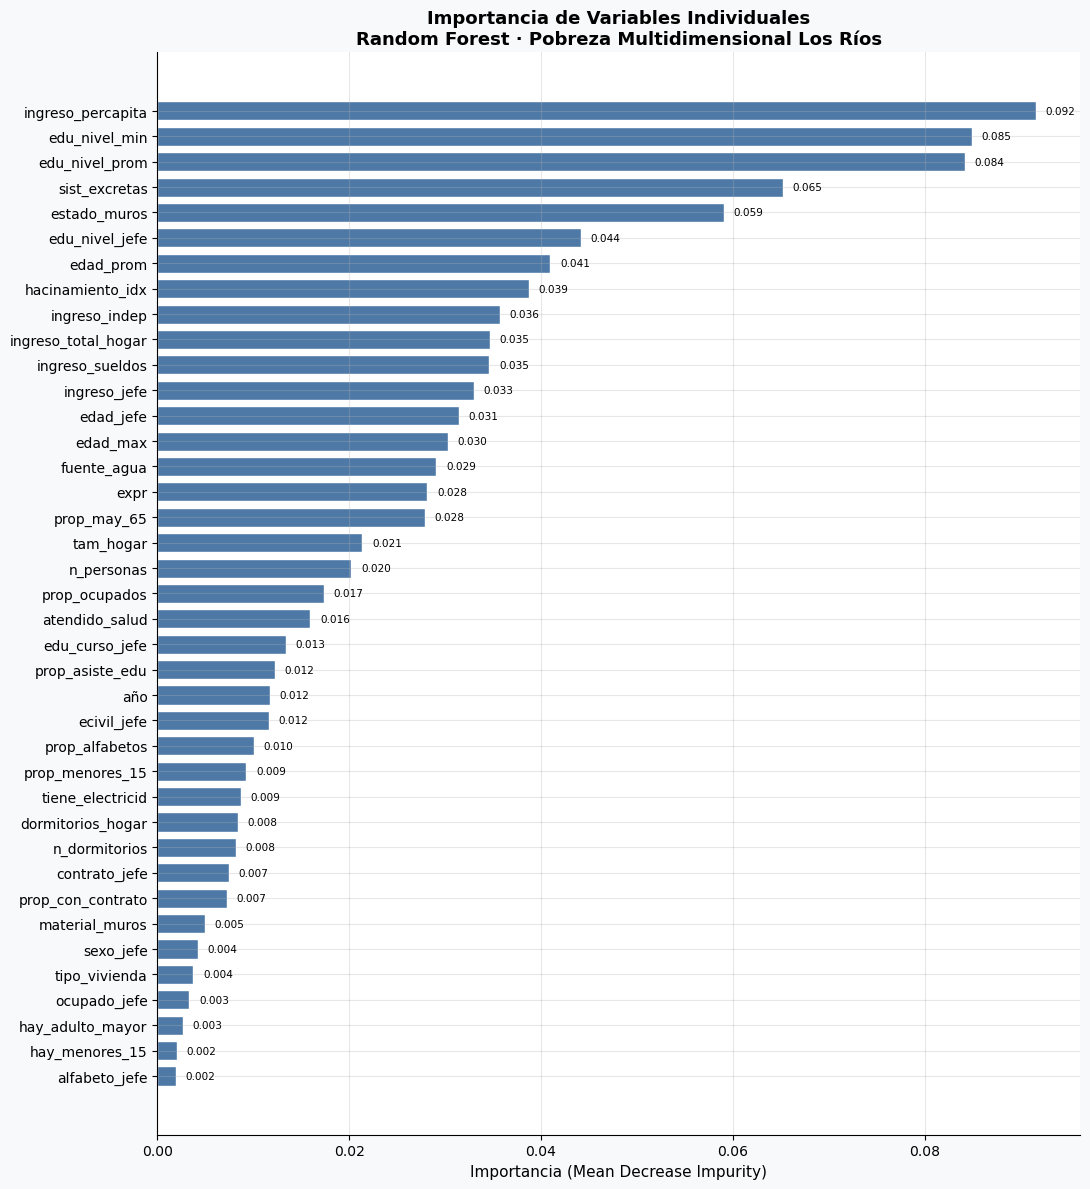

In [6]:
imp = pd.Series(rf_full.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 12))
bars = ax.barh(imp.index, imp.values, color="#4e79a7", edgecolor="white", height=0.75)
ax.set_xlabel("Importancia (Mean Decrease Impurity)", fontsize=11)
ax.set_title("Importancia de Variables Individuales\nRandom Forest · Pobreza Multidimensional Los Ríos",
             fontsize=13, fontweight="bold")

for bar, v in zip(bars, imp.values):
    ax.text(v + 0.001, bar.get_y() + bar.get_height()/2,
            f"{v:.3f}", va="center", fontsize=7.5)

plt.tight_layout()
plt.show()


## 7. Construcción de índices por dimensión IPM

In [7]:
scaler = MinMaxScaler()

def indice(df_src, cols, invertir=None):
    cols_ok = [c for c in cols if c in df_src.columns]
    sub = df_src[cols_ok].copy()
    for c in cols_ok:
        sub[c] = sub[c].fillna(sub[c].median())
    scaled = pd.DataFrame(scaler.fit_transform(sub), columns=cols_ok, index=df_src.index)
    if invertir:
        for c in [c for c in invertir if c in scaled.columns]:
            scaled[c] = 1 - scaled[c]
    return scaled.mean(axis=1)

df_idx = df[df["pobreza_multi"].notna()].copy().reset_index(drop=True)

df_idx["idx_educacion"] = indice(df_idx,
    cols=["edu_nivel_jefe","edu_nivel_prom","edu_nivel_min",
          "prop_alfabetos","prop_asiste_edu","alfabeto_jefe"],
    invertir=["edu_nivel_jefe","edu_nivel_prom","edu_nivel_min",
              "prop_alfabetos","prop_asiste_edu"])

df_idx["idx_vivienda"] = indice(df_idx,
    cols=["material_muros","fuente_agua","sist_excretas",
          "tiene_electricid","hacinamiento_idx","n_dormitorios"],
    invertir=["tiene_electricid","n_dormitorios"])

df_idx["idx_composicion"] = indice(df_idx,
    cols=["tam_hogar","prop_menores_15","prop_may_65",
          "hay_adulto_mayor","n_personas"],
    invertir=[])

df_idx["idx_ingresos"] = indice(df_idx,
    cols=["ingreso_percapita","ingreso_total_hogar","ingreso_jefe",
          "prop_ocupados","prop_con_contrato","contrato_jefe"],
    invertir=["ingreso_percapita","ingreso_total_hogar","ingreso_jefe",
              "prop_ocupados","prop_con_contrato","contrato_jefe"])

INDICES = ["idx_educacion","idx_vivienda","idx_composicion","idx_ingresos"]



## 8. Entrenamiento — modelo con 4 dimensiones

In [8]:
X_idx = df_idx[INDICES].copy()
y_idx = df_idx["pobreza_multi"].copy()

X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_idx, y_idx, test_size=0.2, random_state=42, stratify=y_idx
)

# Reusar mejores hiperparámetros del modelo anterior
rf_idx = RandomForestClassifier(
    **{k:v for k,v in gs.best_params_.items()},
    random_state=42, n_jobs=-1
)
rf_idx.fit(X_tr_i, y_tr_i)

y_pred_idx  = rf_idx.predict(X_te_i)
y_proba_idx = rf_idx.predict_proba(X_te_i)[:,1]
auc_idx     = roc_auc_score(y_te_i, y_proba_idx)

print("=== Modelo 4 Dimensiones ===")
print(classification_report(y_te_i, y_pred_idx, target_names=["No pobre","Pobre"]))
print(f"AUC-ROC: {auc_idx:.4f}")


=== Modelo 4 Dimensiones ===
              precision    recall  f1-score   support

    No pobre       0.90      0.84      0.87      1115
       Pobre       0.38      0.52      0.44       207

    accuracy                           0.79      1322
   macro avg       0.64      0.68      0.65      1322
weighted avg       0.82      0.79      0.80      1322

AUC-ROC: 0.7882


## 9. Importancia por dimensión IPM

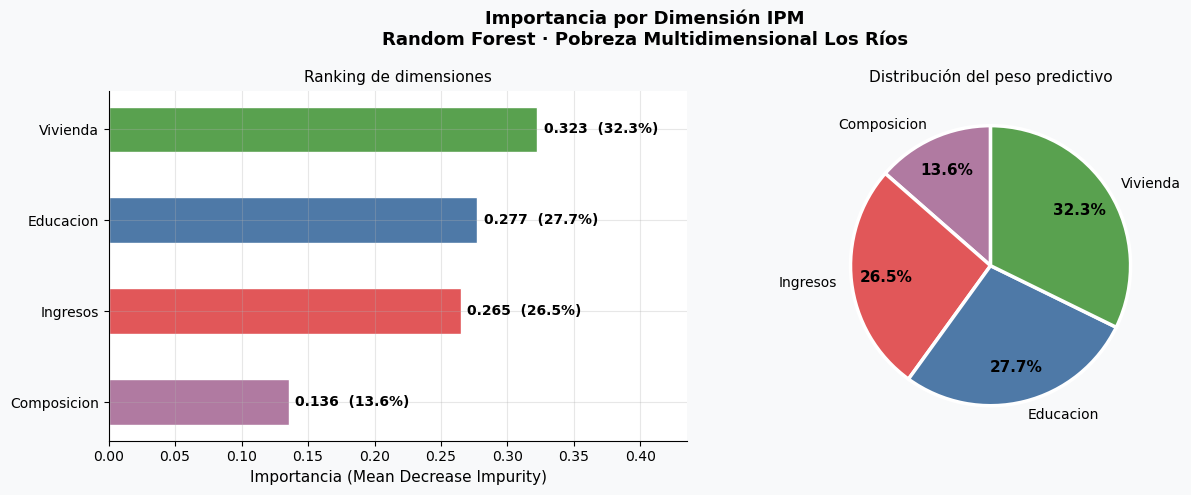

In [9]:
imp_idx = pd.Series(rf_idx.feature_importances_, index=INDICES)
imp_idx.index = [i.replace("idx_","").capitalize() for i in imp_idx.index]
imp_idx = imp_idx.sort_values(ascending=True)

COLS_DIM = {
    "Educacion":   "#4e79a7",
    "Vivienda":    "#59a14f",
    "Composicion": "#b07aa1",
    "Ingresos":    "#e15759",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Importancia por Dimensión IPM\nRandom Forest · Pobreza Multidimensional Los Ríos",
             fontsize=13, fontweight="bold")

# Barras
colores_b = [COLS_DIM.get(d, "#aaa") for d in imp_idx.index]
bars = axes[0].barh(imp_idx.index, imp_idx.values,
                    color=colores_b, edgecolor="white", height=0.5)
axes[0].set_xlabel("Importancia (Mean Decrease Impurity)", fontsize=11)
axes[0].set_title("Ranking de dimensiones", fontsize=11)
for bar, v in zip(bars, imp_idx.values):
    axes[0].text(v + 0.005, bar.get_y() + bar.get_height()/2,
                 f"{v:.3f}  ({v/imp_idx.sum()*100:.1f}%)",
                 va="center", fontsize=10, fontweight="bold")
axes[0].set_xlim(0, imp_idx.max() * 1.35)

# Torta
colores_p = [COLS_DIM.get(d, "#aaa") for d in imp_idx.index]
wedges, texts, autotexts = axes[1].pie(
    imp_idx.values, labels=imp_idx.index, colors=colores_p,
    autopct="%1.1f%%", startangle=90, pctdistance=0.75,
    wedgeprops={"edgecolor":"white","linewidth":2.5}
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight("bold")
axes[1].set_title("Distribución del peso predictivo", fontsize=11)

plt.tight_layout()
plt.show()

## 10. Comparación: modelo completo vs 4 dimensiones

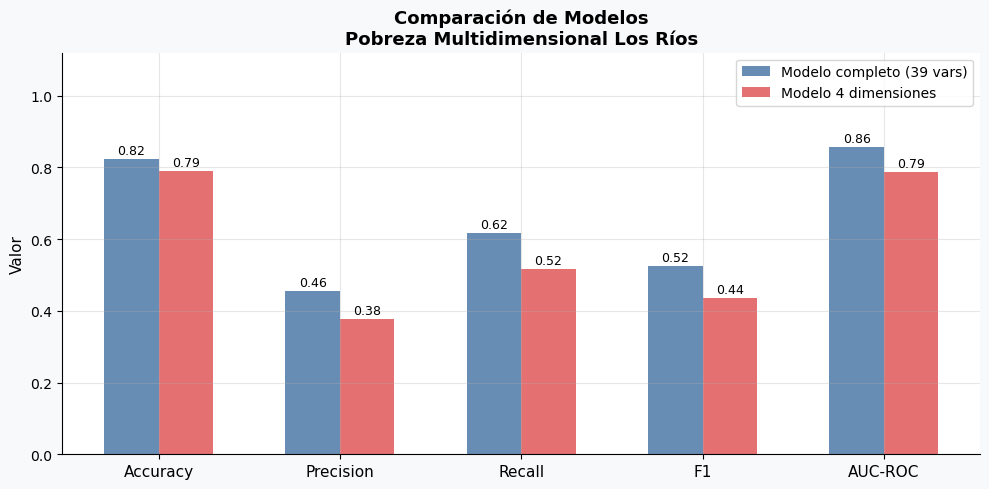

In [10]:
metricas_nombres = ["Accuracy","Precision","Recall","F1","AUC-ROC"]
vals_full = [
    accuracy_score(y_test,   y_pred_full),
    precision_score(y_test,  y_pred_full),
    recall_score(y_test,     y_pred_full),
    f1_score(y_test,         y_pred_full),
    auc_full
]
vals_idx = [
    accuracy_score(y_te_i,   y_pred_idx),
    precision_score(y_te_i,  y_pred_idx),
    recall_score(y_te_i,     y_pred_idx),
    f1_score(y_te_i,         y_pred_idx),
    auc_idx
]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metricas_nombres)); w = 0.3

b1 = ax.bar(x - w/2, vals_full, w, label=f"Modelo completo ({len(FEATURES)} vars)",
            color="#4e79a7", alpha=0.85)
b2 = ax.bar(x + w/2, vals_idx,  w, label="Modelo 4 dimensiones",
            color="#e15759", alpha=0.85)

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metricas_nombres, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Valor", fontsize=11)
ax.set_title("Comparación de Modelos\nPobreza Multidimensional Los Ríos",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()



## 11. Análisis por comuna

In [11]:
# Predicciones sobre dataset completo (con comuna)
df_com = df[df["pobreza_multi"].notna()].copy().reset_index(drop=True)

# Para 2017 extraer comuna del folio, para 2024 ya viene en el dataset
def folio_a_comuna(folio):
    MAPA = {
        14101:"Valdivia",  14102:"Corral",    14103:"Lanco",
        14104:"Los Lagos", 14105:"Máfil",     14106:"Mariquina",
        14107:"Paillaco",  14108:"Panguipulli",14201:"La Unión",
        14202:"Futrono",   14203:"Lago Ranco", 14204:"Río Bueno",
    }
    try:
        s = str(int(folio))
        if len(s) == 13:
            return MAPA.get(int("14" + s[2:5]))
    except:
        pass
    return None

# Rellenar columna comuna
if "comuna" not in df_com.columns or df_com["comuna"].isna().all():
    df_com["comuna"] = df_com["folio"].apply(folio_a_comuna)
else:
    mask_sin = df_com["comuna"].isna()
    df_com.loc[mask_sin, "comuna"] = df_com.loc[mask_sin, "folio"].apply(folio_a_comuna)

# Preparar X para predicción completa (mismo preprocesamiento)
df_ml2 = df_com.copy()
for col in CATS:
    if col in df_ml2.columns:
        df_ml2[col] = df_ml2[col].astype(str).fillna("desconocido")
        le2 = LabelEncoder()
        df_ml2[col] = le2.fit_transform(df_ml2[col])

X_all = df_ml2[FEATURES].copy()
df_com["prediccion"] = rf_full.predict(X_all)
df_com["prob_pobre"] = rf_full.predict_proba(X_all)[:,1]
df_com["correcto"]   = (df_com["pobreza_multi"] == df_com["prediccion"]).astype(int)

print(f"Comunas disponibles: {df_com['comuna'].notna().sum()}/{len(df_com)}")


Comunas disponibles: 6608/6608


In [12]:
# Resumen por comuna
resumen = df_com.groupby("comuna").agg(
    n_hogares       = ("pobreza_multi","count"),
    pct_pobre_real  = ("pobreza_multi","mean"),
    pct_pobre_pred  = ("prediccion",  "mean"),
    precision_local = ("correcto",    "mean"),
    prob_prom       = ("prob_pobre",  "mean"),
).reset_index()

resumen[["pct_pobre_real","pct_pobre_pred","precision_local","prob_prom"]] *= 100
resumen["diferencia"] = resumen["pct_pobre_pred"] - resumen["pct_pobre_real"]
resumen = resumen.sort_values("pct_pobre_real", ascending=False)

print(resumen.to_string(index=False, float_format="{:.1f}".format))


     comuna  n_hogares  pct_pobre_real  pct_pobre_pred  precision_local  prob_prom  diferencia
     Corral        139            23.7            36.7             85.6       41.0        12.9
 Lago Ranco        156            23.7            36.5             79.5       39.1        12.8
    Futrono        238            23.5            31.5             89.5       36.3         8.0
Panguipulli        480            23.1            31.7             86.0       37.6         8.5
  Los Lagos        299            22.7            30.8             85.3       38.7         8.0
      Máfil        159            22.0            34.0             85.5       35.9        11.9
  Río Bueno        567            19.8            30.2             86.8       34.5        10.4
  Mariquina        394            16.0            28.9             82.5       35.5        12.9
      Lanco        251            15.9            27.1             85.7       33.8        11.2
   Paillaco        328            14.9            

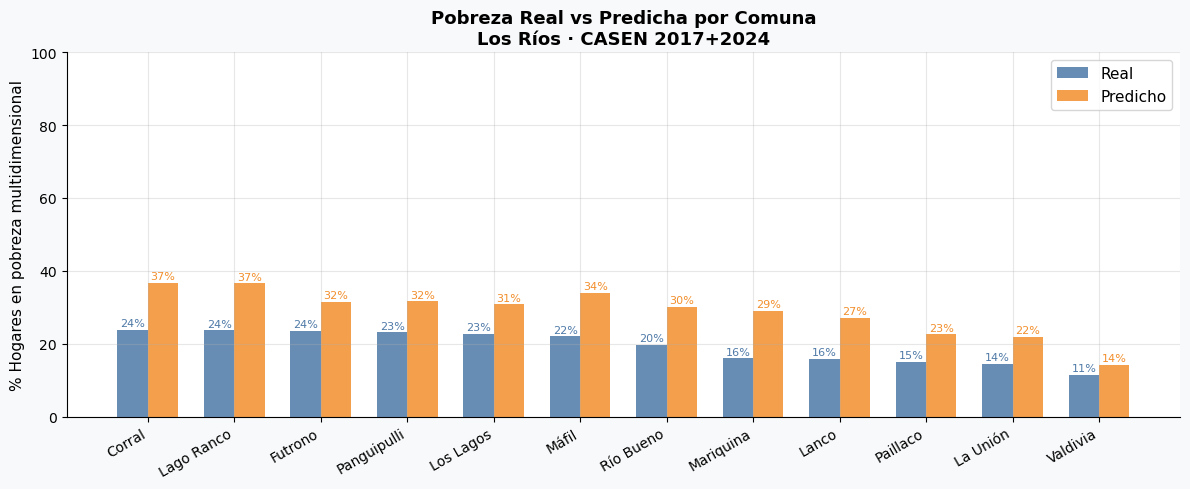

In [13]:
# ── Gráfico 1: pobreza real vs predicha por comuna ──────────────
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(resumen)); w = 0.35

ax.bar(x - w/2, resumen["pct_pobre_real"], w, label="Real",
       color="#4e79a7", alpha=0.85)
ax.bar(x + w/2, resumen["pct_pobre_pred"], w, label="Predicho",
       color="#f28e2b", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(resumen["comuna"], rotation=30, ha="right", fontsize=10)
ax.set_ylabel("% Hogares en pobreza multidimensional", fontsize=11)
ax.set_title("Pobreza Real vs Predicha por Comuna\nLos Ríos · CASEN 2017+2024",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.set_ylim(0, 100)

for i, (real, pred) in enumerate(zip(resumen["pct_pobre_real"], resumen["pct_pobre_pred"])):
    ax.text(i - w/2, real + 1, f"{real:.0f}%", ha="center", fontsize=8, color="#4e79a7")
    ax.text(i + w/2, pred + 1, f"{pred:.0f}%", ha="center", fontsize=8, color="#f28e2b")

plt.tight_layout()
plt.show()


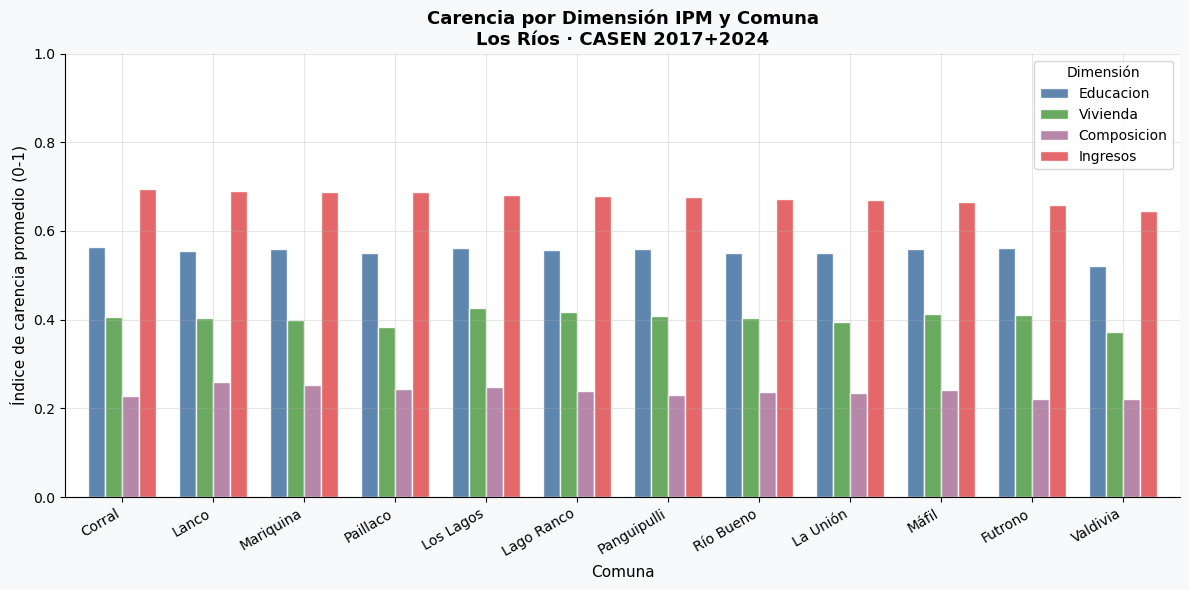

In [14]:
# ── Gráfico 2: índices de carencia por dimensión y comuna ────────
resumen_dim = df_idx.copy()
resumen_dim["comuna"] = df_com["comuna"].values

if resumen_dim["comuna"].notna().sum() > 0:
    dim_comuna = resumen_dim.groupby("comuna")[INDICES].mean()
    dim_comuna.columns = [c.replace("idx_","").capitalize() for c in dim_comuna.columns]
    dim_comuna = dim_comuna.sort_values("Ingresos", ascending=False)

    fig, ax = plt.subplots(figsize=(12, 6))
    dim_comuna.plot(kind="bar", ax=ax,
                   color=[COLS_DIM.get(c,"#aaa") for c in dim_comuna.columns],
                   edgecolor="white", width=0.75, alpha=0.9)
    ax.set_xlabel("Comuna", fontsize=11)
    ax.set_ylabel("Índice de carencia promedio (0-1)", fontsize=11)
    ax.set_title("Carencia por Dimensión IPM y Comuna\nLos Ríos · CASEN 2017+2024",
                 fontsize=13, fontweight="bold")
    ax.set_xticklabels(dim_comuna.index, rotation=30, ha="right", fontsize=10)
    ax.legend(title="Dimensión", fontsize=10)
    ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Sin datos de comuna disponibles")


## 12. Evaluación final — Matriz de confusión y ROC

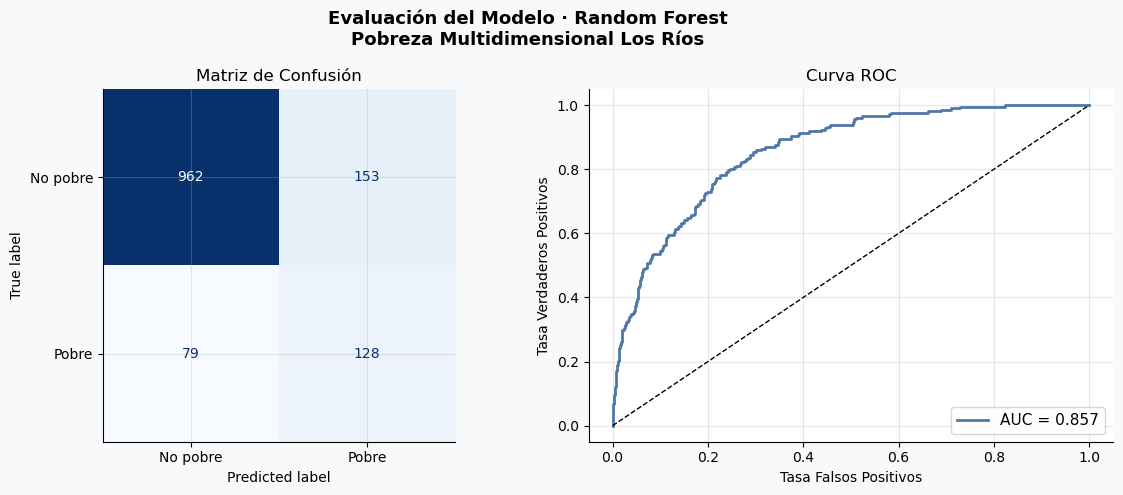

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Evaluación del Modelo · Random Forest\nPobreza Multidimensional Los Ríos",
             fontsize=13, fontweight="bold")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_full)
ConfusionMatrixDisplay(cm, display_labels=["No pobre","Pobre"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusión", fontsize=12)

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_full)
axes[1].plot(fpr, tpr, color="#4e79a7", lw=2, label=f"AUC = {auc_full:.3f}")
axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].set_xlabel("Tasa Falsos Positivos"); axes[1].set_ylabel("Tasa Verdaderos Positivos")
axes[1].set_title("Curva ROC", fontsize=12)
axes[1].legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()

## 13. Guardar modelos para el dashboard

In [16]:
import joblib

# Guardar mask del clustering para uso posterior
MASK_CLUSTER = df_idx[INDICES].notna().all(axis=1) & df_idx["pobreza_multi"].notna()

# Los archivos se guardan en la misma carpeta donde está este notebook
joblib.dump(rf_idx,   "modelo_rf_idx.pkl")
joblib.dump(rf_full,  "modelo_rf_full.pkl")
joblib.dump(INDICES,  "indices_cluster.pkl")
df_idx.to_csv("df_idx.csv", index=False)

print("✅ Modelos guardados:")
print("   modelo_rf_idx.pkl")
print("   modelo_rf_full.pkl")
print("   indices_cluster.pkl")
print("   df_idx.csv")


✅ Modelos guardados:
   modelo_rf_idx.pkl
   modelo_rf_full.pkl
   indices_cluster.pkl
   df_idx.csv


## 14. Resumen final

In [17]:
imp_dim = pd.Series(rf_idx.feature_importances_, index=INDICES)
imp_dim.index = [i.replace("idx_","").capitalize() for i in imp_dim.index]
top_dim = imp_dim.sort_values(ascending=False)

print("╔══════════════════════════════════════════════════════╗")
print("║   RANDOM FOREST — RESUMEN FINAL                      ║")
print("║   Pobreza Multidimensional Los Ríos                  ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Hogares analizados:   {len(y):>6,}                      ║")
print(f"║  Features (modelo completo): {len(FEATURES):>3}                   ║")
print("╠══════════════════════════════════════════════════════╣")
print("║  MODELO COMPLETO                                      ║")
print(f"║  Accuracy:  {accuracy_score(y_test,y_pred_full):.1%}  |  F1: {f1_score(y_test,y_pred_full):.1%}  |  AUC: {auc_full:.4f}  ║")
print("╠══════════════════════════════════════════════════════╣")
print("║  MODELO 4 DIMENSIONES IPM                            ║")
print(f"║  Accuracy:  {accuracy_score(y_te_i,y_pred_idx):.1%}  |  F1: {f1_score(y_te_i,y_pred_idx):.1%}  |  AUC: {auc_idx:.4f}  ║")
print("╠══════════════════════════════════════════════════════╣")
print("║  FACTORES PREDOMINANTES:                             ║")
for i, (dim, val) in enumerate(top_dim.items(), 1):
    barra = "█" * int(val * 30)
    print(f"║  {i}. {dim:<14} {val:.3f}  {barra:<20}          ║")
print("╚══════════════════════════════════════════════════════╝")
print(f"\n→ La dimensión dominante es: {top_dim.index[0]}")
print(f"  Explica el {top_dim.iloc[0]/top_dim.sum()*100:.1f}% del peso predictivo del modelo.")


╔══════════════════════════════════════════════════════╗
║   RANDOM FOREST — RESUMEN FINAL                      ║
║   Pobreza Multidimensional Los Ríos                  ║
╠══════════════════════════════════════════════════════╣
║  Hogares analizados:    6,608                      ║
║  Features (modelo completo):  39                   ║
╠══════════════════════════════════════════════════════╣
║  MODELO COMPLETO                                      ║
║  Accuracy:  82.5%  |  F1: 52.5%  |  AUC: 0.8567  ║
╠══════════════════════════════════════════════════════╣
║  MODELO 4 DIMENSIONES IPM                            ║
║  Accuracy:  79.1%  |  F1: 43.7%  |  AUC: 0.7882  ║
╠══════════════════════════════════════════════════════╣
║  FACTORES PREDOMINANTES:                             ║
║  1. Vivienda       0.323  █████████                     ║
║  2. Educacion      0.277  ████████                      ║
║  3. Ingresos       0.265  ███████                       ║
║  4. Composicion    0.136  ████ 